# Lab 04: The Scaling Relation That Depends on How You Fit It

**ASTR 457, Fall 2026, posted Thu Sep 24, due Wed Sep 30 by Noon (fork → PR, as always)**

**Extra credit, +5 points on this lab:** if you attended Charlotte Ward's Sep 22 Astronomy Colloquium, turn in at least a page of notes including two questions you had, as a text file in your `submissions/<netid>/` folder, by Noon Tue Sep 29.

*Why this lab: every scaling relation you will ever use ($M_{\rm BH}$–$\sigma$, Tully–Fisher, the mass–metallicity relation, the SN Ia standardization) was fit by someone who chose a regression method, and the choice changes the published slope. Knowing when ordinary least squares lies, by how much, and what to do instead is how you read those papers, and how you referee them.*

Every one of you has your own dataset: `data/<your netid>.csv`, a sample of dwarf
galaxies hosting active galactic nuclei, selected by their optical variability in the
style of Ward et al. (2022, arXiv:2110.13098). Dwarf-galaxy AGN are one of the few
windows we have on black holes in the $10^5$–$10^7\,M_\odot$ range, where the seeds of
supermassive black holes hide. Columns:

- `logMstar`, `err_logMstar`: $x = \log_{10}(M_*/M_\odot)$, the host stellar mass from
  SED fitting, and its $1\sigma$ uncertainty (0.2–0.4 dex; dwarf-galaxy photometry is hard),
- `logMBH`, `err_logMBH`: $y = \log_{10}(M_{\rm BH}/M_\odot)$, the virial black-hole
  mass from broad-line spectroscopy, and its $1\sigma$ uncertainty.

The relation you are after is

$$y = \alpha\,(x - 9.5) + \beta + \text{intrinsic scatter } \sigma_{\rm int},$$

pivoted at $M_* = 10^{9.5} M_\odot$ so $\alpha$ and $\beta$ don't fight each other. **Both
variables have measurement error, and the relation has real astrophysical scatter on top.**
I know your true $\alpha$, $\beta$, and $\sigma_{\rm int}$. You don't, your classmates'
values are different from yours, and so are your sample sizes.

**How this is graded.** Not on whether your code runs, but on whether your answers are
*right* and your uncertainties are *honest*. Part of your grade comes from how close your
reported $\alpha$ and $\beta$ are to your truth **in units of your own reported
uncertainty**. Tiny error bars you can't back up lose points; padded ones lose points too.
Calibration is the skill. The floor under "padded": your reported $\sigma_\alpha$ may not
exceed **3× the curvature uncertainty of your own generative fit** from Part 2 (if your
Hessian turns out singular, quote a profile-likelihood width instead and say so). Bigger
than that is not caution, since it's an estimator you should have discarded.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The fit everyone does first (15%)

Load your sample and plot it with error bars **on both axes**. Then fit the relation the
way most papers still do: **ordinary least squares** on $y$ vs $(x - 9.5)$, every point
weighted equally, errors ignored. Build the design matrix and solve the normal equations
yourself (lecture machinery, or `np.polyfit` if you must, but know what it's doing). Report
$\hat\alpha \pm \sigma$ using the standard OLS variance estimate, $s^2 (A^{\mathsf T}A)^{-1}$
with $s^2 = \mathrm{RSS}/(N-2)$ (residual-scaled; the errors play no role yet, on purpose).

Then answer, in a few sentences: which of OLS's assumptions does *your* dataset violate?
For the slope specifically, which way does the bias from the $x$-errors pull, and what
controls its size? (We named it in lecture on Sep 24. The effect is *supposed*
to be there; understanding exactly why, on your own data, is the point of this lab.)

alpha = 1.088379212817674 +/- 0.15950824089149926
beta = 6.1408764066784896 +/- 0.10049627569629876


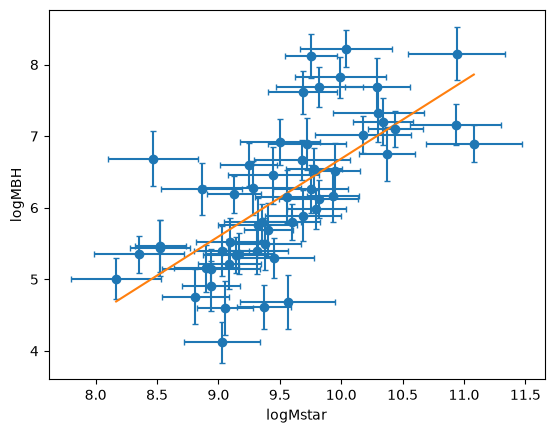

In [3]:
# Part 1: your work here

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/nraja3.csv")

x = df["logMstar"].to_numpy()
sx = df["err_logMstar"].to_numpy()
y = df["logMBH"].to_numpy()
sy = df["err_logMBH"].to_numpy()

xp = x - 9.5

A = np.column_stack((xp, np.ones(len(x))))

params = np.linalg.inv(A.T @ A) @ A.T @ y

alpha = params[0]
beta = params[1]

yfit = alpha * xp + beta
res = y - yfit

rss = np.sum(res**2)
s2 = rss / (len(x) - 2)

cov = s2 * np.linalg.inv(A.T @ A)

alpha_err = np.sqrt(cov[0, 0])
beta_err = np.sqrt(cov[1, 1])

print("alpha =", alpha, "+/-", alpha_err)
print("beta =", beta, "+/-", beta_err)

plt.errorbar(x, y, xerr=sx, yerr=sy, fmt="o", capsize=2)

xx = np.linspace(x.min(), x.max(), 100)
plt.plot(xx, alpha * (xx - 9.5) + beta)

plt.xlabel("logMstar")
plt.ylabel("logMBH")
plt.show()

**ANSWER (a few sentences):**

*OLS assumes the x-values are exact, but our logMstar values have errors, and it also ignores the different y-errors and the extra scatter in the data. The x-errors make the slope too shallow making the line too flat. The bigger the x-errors are compared to the real spread in x, the bigger the bias.*

## Part 2: Estimators you can defend (40%)

Now fit the relation **three more ways** and compare:

1. **Weighted least squares** using the $y$-errors only:
   $\hat{\theta} = (A^{\mathsf T}\Sigma^{-1}A)^{-1}A^{\mathsf T}\Sigma^{-1}y$ with
   $\Sigma = \mathrm{diag}(\sigma_{y,i}^2)$, parameter covariance
   $(A^{\mathsf T}\Sigma^{-1}A)^{-1}$. Does weighting fix the Part 1 bias? Why or why not?

2. **Orthogonal distance regression** (`scipy.odr`, which warns that it is deprecated on
   import; that is fine in the course environment), which knows about the $x$-errors.
   Read what it minimizes before you run it. What does ODR assume about scatter
   *perpendicular to the relation*, and is that assumption true here?

3. **The generative model, honestly.** Write down where each data point comes from:
   the true stellar masses are drawn from the population,
   $x_i^{\rm true} \sim \mathcal{N}(\mu, \sigma_{\rm pop}^2)$; the relation plus intrinsic scatter
   makes the true BH mass; and your measurement errors corrupt both. Marginalizing over
   the (unobservable) true masses makes each observed pair $(x_i, y_i)$ a **bivariate
   Gaussian**:

   $$\begin{pmatrix} x_i \\ y_i \end{pmatrix} \sim \mathcal{N}\!\left[
   \begin{pmatrix} \mu \\ \alpha(\mu - 9.5) + \beta \end{pmatrix},\;
   \begin{pmatrix} \sigma_{\rm pop}^2 + \sigma_{x,i}^2 & \alpha\,\sigma_{\rm pop}^2 \\
   \alpha\,\sigma_{\rm pop}^2 & \alpha^2\sigma_{\rm pop}^2 + \sigma_{\rm int}^2 + \sigma_{y,i}^2 \end{pmatrix}
   \right]$$

   (Convince yourself of the three variance entries before you code; the off-diagonal
   covariance is what removes the attenuation bias. This is the Gaussian core of Kelly 2007, the paper behind
   every modern `linmix`-style fit.) Maximize the summed log-likelihood over all five
   parameters $(\alpha, \beta, \sigma_{\rm int}, \mu, \sigma_{\rm pop})$, and get uncertainties from
   the curvature of the log-likelihood at its peak (the observed information), and say so.

Make **one plot with all four fitted lines overplotted** on your data. They will not agree.
Explain, estimator by estimator, *why* each lands where it does, and which ingredient of the
data each one ignores.

Commit to a **final answer**: one $\alpha \pm \sigma$, $\beta \pm \sigma$, and
$\sigma_{\rm int} \pm \sigma$ you'd put in a paper, and justify the choice. Remember the
3× rule from the header.

In [6]:
# Part 2: your work here

w = 1 / sy**2

A = np.column_stack((x - 9.5, np.ones(len(x))))
W = np.diag(w)

cov_wls = np.linalg.inv(A.T @ W @ A)
p_wls = cov_wls @ A.T @ W @ y

alpha_wls = p_wls[0]
beta_wls = p_wls[1]

alpha_wls_err = np.sqrt(cov_wls[0, 0])
beta_wls_err = np.sqrt(cov_wls[1, 1])

print("WLS alpha =", alpha_wls, "+/-", alpha_wls_err)
print("WLS beta =", beta_wls, "+/-", beta_wls_err)

WLS alpha = 1.0783685003199839 +/- 0.06603859301283066
WLS beta = 6.1399934603288076 +/- 0.04227511858109167


In [7]:
from scipy import odr

def line(B, x):
    return B[0] * (x - 9.5) + B[1]

model = odr.Model(line)
data = odr.RealData(x, y, sx=sx, sy=sy)

fit = odr.ODR(data, model, beta0=[alpha, beta])
out = fit.run()

alpha_odr = out.beta[0]
beta_odr = out.beta[1]

alpha_odr_err = out.sd_beta[0]
beta_odr_err = out.sd_beta[1]

print("ODR alpha =", alpha_odr, "+/-", alpha_odr_err)
print("ODR beta =", beta_odr, "+/-", beta_odr_err)

ODR alpha = 1.9509553370564394 +/- 0.24237642493035227
ODR beta = 6.1090533743121345 +/- 0.11803277676042083


In [10]:
from scipy.optimize import minimize

def nll(p):
    a = p[0]
    b = p[1]
    sint = p[2]
    mu = p[3]
    spop = p[4]

    if sint <= 0 or spop <= 0:
        return 1e100

    total = 0

    for i in range(len(x)):
        vx = spop**2 + sx[i]**2
        cxy = a * spop**2
        vy = a**2 * spop**2 + sint**2 + sy[i]**2

        det = vx * vy - cxy**2

        dx = x[i] - mu
        dy = y[i] - (a * (mu - 9.5) + b)

        q = (vy * dx**2 - 2 * cxy * dx * dy + vx * dy**2) / det

        total = total + 0.5 * (np.log(det) + q + 2 * np.log(2 * np.pi))

    return total
    
start = [
    alpha,
    beta,
    0.5,
    np.mean(x),
    np.std(x)
]

result = minimize(
    nll,
    start,
    method="Nelder-Mead",
    options={"maxiter":20000}
)

p = result.x

alpha_gen = p[0]
beta_gen = p[1]
sint_gen = p[2]
mu_gen = p[3]
spop_gen = p[4]

print("alpha =", alpha_gen)
print("beta =", beta_gen)
print("sigma_int =", sint_gen)
print("mu =", mu_gen)
print("sigma_pop =", spop_gen)

alpha = 1.5197748733049448
beta = 6.1328696429199345
sigma_int = 0.5159684133481145
mu = 9.515383671891115
sigma_pop = 0.5274400839390437


In [11]:
def hessian(f, p):
    n = len(p)
    H = np.zeros((n, n))
    h = 0.0001

    for i in range(n):
        for j in range(n):
            ei = np.zeros(n)
            ej = np.zeros(n)

            ei[i] = h
            ej[j] = h

            H[i, j] = (
                f(p + ei + ej)
                - f(p + ei - ej)
                - f(p - ei + ej)
                + f(p - ei - ej)
            ) / (4 * h**2)

    return H

H = hessian(nll, p)

cov_gen = np.linalg.inv(H)

err_gen = np.sqrt(np.diag(cov_gen))

alpha_gen_err = err_gen[0]
beta_gen_err = err_gen[1]
sint_gen_err = err_gen[2]
mu_gen_err = err_gen[3]
spop_gen_err = err_gen[4]

print("Generative alpha =", alpha_gen, "+/-", alpha_gen_err)
print("Generative beta =", beta_gen, "+/-", beta_gen_err)
print("Generative sigma_int =", sint_gen, "+/-", sint_gen_err)
print("mu =", mu_gen, "+/-", mu_gen_err)
print("sigma_pop =", spop_gen, "+/-", spop_gen_err)

Generative alpha = 1.5197748733049448 +/- 0.2318625582444728
Generative beta = 6.1328696429199345 +/- 0.10160342285496907
Generative sigma_int = 0.5159684133481145 +/- 0.10385162217414282
mu = 9.515383671891115 +/- 0.08117094156565983
sigma_pop = 0.5274400839390437 +/- 0.06687457605398375


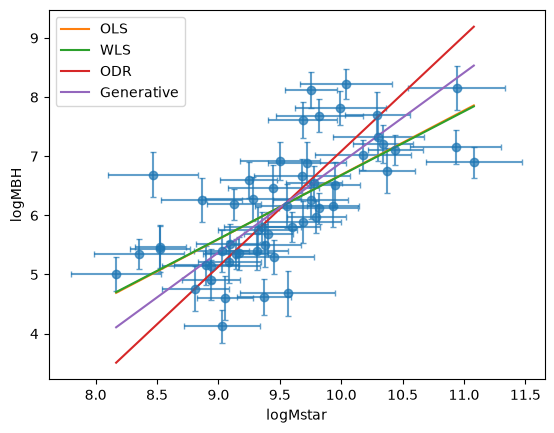

In [12]:
xx = np.linspace(x.min(), x.max(), 200)

plt.errorbar(
    x,
    y,
    xerr=sx,
    yerr=sy,
    fmt="o",
    capsize=2,
    alpha=0.7
)

plt.plot(xx, alpha * (xx - 9.5) + beta, label="OLS")
plt.plot(xx, alpha_wls * (xx - 9.5) + beta_wls, label="WLS")
plt.plot(xx, alpha_odr * (xx - 9.5) + beta_odr, label="ODR")
plt.plot(xx, alpha_gen * (xx - 9.5) + beta_gen, label="Generative")

plt.xlabel("logMstar")
plt.ylabel("logMBH")
plt.legend()
plt.show()

**FINAL ANSWER:** $\alpha = $ 1.5198 $\pm$ 0.2319, $\beta = $ 6.1328 $\pm$ 0.1016 , $\sigma_{\rm int} = $ 0.516 $\pm$ 0.103 dex

**Justification and uncertainty method (a short paragraph):**

*OLS ignores all errors. WLS only uses y-errors. ODR uses x and y errors but does not model the intrinsic scatter correctly. The generative model includes x-errors, y-errors, intrinsic scatter, and the x population, so I feel that it is the best.*

## Part 3: The verification plan, written first and then executed (35%)

**Before you run anything below, write the plan** (3a). A verification plan you invent
after seeing the results is a rationalization.

**3a. The plan.** List the checks you will run to decide whether to trust your Part 2
numbers. At minimum, address:

1. **Closure**: simulate a dataset with a truth *you* choose (the generative recipe in
   Part 2 tells you exactly how) and confirm your fit recovers it.
2. **Bias and efficiency**: Monte Carlo all four estimators on many simulated datasets at
   plausible parameters. Plot each estimator's bias and variance for $\alpha$. This is
   *the* figure of this lab.
3. **Coverage**: across your simulations, do your 68% intervals contain the truth 68% of
   the time, for all three reported parameters?
4. **Sensitivity**: what happens to $\hat\alpha$ if the catalog $x$-errors are wrong by
   ±50% (generate correctly, fit with the mis-stated errors)? If the true population isn't Gaussian (try drawing $x^{\rm true}$ from a uniform
   distribution with the same mean and variance instead)? If you had assumed $\sigma_{\rm int} = 0$?

For **each** check, state *in advance* what failure would look like. A check that cannot
fail is not a check.

**3b. The execution.** Run the plan. Report what each check found, including anything that
failed or surprised you. A failed check honestly reported and diagnosed is worth more than
a wall of green checkmarks.

**VERIFICATION PLAN (write this before running 3b):**

*Closure: I will simulate data with known values and see if the fit gets close to them. Failure would be if the fit is more than about 1–2 sigma away.
Bias and efficiency: I will run many simulations and compare OLS, WLS, ODR, and the generative model. A method fails if its average slope is far from the true slope.
Coverage: I will check how often the 68% intervals include the true values. It should be around 68%.
Sensitivity: I will change the x-errors, the x population shape, and remove intrinsic scatter. If alpha changes a lot, then the fit is sensitive to that assumption.*

In [17]:
# Part 3b: execute the plan here

xreal = x.copy()
yreal = y.copy()
sxreal = sx.copy()
syreal = sy.copy()

true_alpha = 1.5
true_beta = 6.1
true_sint = 0.5
true_mu = 9.5
true_spop = 0.53

xt = np.random.normal(true_mu, true_spop, len(xreal))
yt = true_alpha * (xt - 9.5) + true_beta
yt = yt + np.random.normal(0, true_sint, len(xreal))

x = xt + np.random.normal(0, sxreal)
y = yt + np.random.normal(0, syreal)
sx = sxreal.copy()
sy = syreal.copy()

r = minimize(nll, [1.5, 6.1, 0.5, 9.5, 0.53], method="Nelder-Mead")

p = r.x
H = hessian(nll, p)
err = np.sqrt(np.diag(np.linalg.inv(H)))

print("alpha =", p[0], "+/-", err[0], "truth =", true_alpha)
print("beta =", p[1], "+/-", err[1], "truth =", true_beta)
print("sigma_int =", p[2], "+/-", err[2], "truth =", true_sint)

alpha = 1.5982207108080209 +/- 0.17611833044647984 truth = 1.5
beta = 6.136731339460029 +/- 0.08562056262981448 truth = 6.1
sigma_int = 0.2749304019125501 +/- 0.12829826019390916 truth = 0.5


OLS mean = 1.1200361879866911 std = 0.1789545840291471
WLS mean = 1.1096707075785297 std = 0.19105479716154336
ODR mean = 1.9611413150824957 std = 0.2993741875241112
Generative mean = 1.5215125786227306 std = 0.2405900754876502
alpha coverage = 0.66
beta coverage = 0.66
sigma_int coverage = 0.6


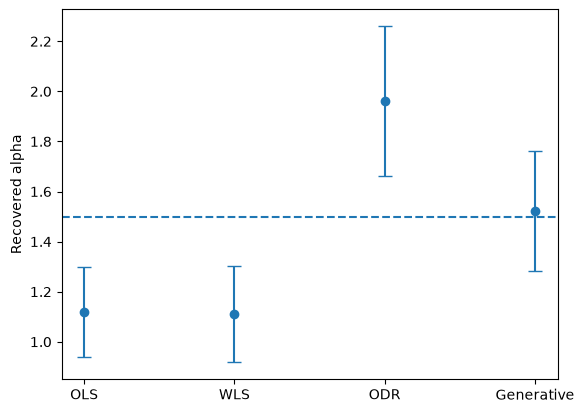

In [21]:
olslist = []
wlslist = []
odrlist = []
genlist = []

ca = 0
cb = 0
cs = 0

nsim = 50

np.random.seed(2)

for k in range(nsim):

    xt = np.random.normal(true_mu, true_spop, len(xreal))
    yt = true_alpha * (xt - 9.5) + true_beta
    yt = yt + np.random.normal(0, true_sint, len(xreal))

    x = xt + np.random.normal(0, sxreal)
    y = yt + np.random.normal(0, syreal)
    sx = sxreal.copy()
    sy = syreal.copy()

    A = np.column_stack((x - 9.5, np.ones(len(x))))

    po = np.linalg.inv(A.T @ A) @ A.T @ y
    olslist.append(po[0])

    W = np.diag(1 / sy**2)
    pw = np.linalg.inv(A.T @ W @ A) @ A.T @ W @ y
    wlslist.append(pw[0])

    data = odr.RealData(x, y, sx=sx, sy=sy)
    out = odr.ODR(data, model, beta0=[1.5, 6.1]).run()
    odrlist.append(out.beta[0])

    r = minimize(nll, [1.5, 6.1, 0.5, 9.5, 0.53], method="Nelder-Mead")
    genlist.append(r.x[0])

    H = hessian(nll, r.x)

    try:
        err = np.sqrt(np.diag(np.linalg.inv(H)))

        ca += abs(r.x[0] - true_alpha) <= err[0]
        cb += abs(r.x[1] - true_beta) <= err[1]
        cs += abs(r.x[2] - true_sint) <= err[2]

    except:
        pass

print("OLS mean =", np.mean(olslist), "std =", np.std(olslist))
print("WLS mean =", np.mean(wlslist), "std =", np.std(wlslist))
print("ODR mean =", np.mean(odrlist), "std =", np.std(odrlist))
print("Generative mean =", np.mean(genlist), "std =", np.std(genlist))

print("alpha coverage =", ca / nsim)
print("beta coverage =", cb / nsim)
print("sigma_int coverage =", cs / nsim)

names = ["OLS", "WLS", "ODR", "Generative"]

means = [
    np.mean(olslist),
    np.mean(wlslist),
    np.mean(odrlist),
    np.mean(genlist)
]

stds = [
    np.std(olslist),
    np.std(wlslist),
    np.std(odrlist),
    np.std(genlist)
]

plt.errorbar(names, means, yerr=stds, fmt="o", capsize=5)
plt.axhline(true_alpha, linestyle="--")
plt.ylabel("Recovered alpha")
plt.show()



In [23]:
np.random.seed(3)

xt = np.random.normal(true_mu, true_spop, len(xreal))
yt = true_alpha * (xt - 9.5) + true_beta
yt = yt + np.random.normal(0, true_sint, len(xreal))

x = xt + np.random.normal(0, sxreal)
y = yt + np.random.normal(0, syreal)
sy = syreal.copy()

sx = sxreal.copy()

r = minimize(nll, [1.5, 6.1, 0.5, 9.5, 0.53], method="Nelder-Mead")

print("correct errors =", r.x[0])

sx = sxreal * 0.5

rsmall = minimize(nll, [1.5, 6.1, 0.5, 9.5, 0.53], method="Nelder-Mead")

print("errors 50% too small =", rsmall.x[0])

sx = sxreal * 1.5

rlarge = minimize(nll, [1.5, 6.1, 0.5, 9.5, 0.53], method="Nelder-Mead")

print("errors 50% too large =", rlarge.x[0])

correct errors = 2.0616409147059223
errors 50% too small = 1.4887187553616426
errors 50% too large = 2.2181917782499854


In [24]:
np.random.seed(4)

width = np.sqrt(12) * true_spop

xt = np.random.uniform(
    true_mu - width/2,
    true_mu + width/2,
    len(xreal)
)

yt = true_alpha * (xt - 9.5) + true_beta
yt = yt + np.random.normal(0, true_sint, len(xreal))

x = xt + np.random.normal(0, sxreal)
y = yt + np.random.normal(0, syreal)

sx = sxreal.copy()
sy = syreal.copy()

runiform = minimize(nll, [1.5, 6.1, 0.5, 9.5, 0.53], method="Nelder-Mead")

print("uniform population alpha =", runiform.x[0])

uniform population alpha = 1.5092923967860514


In [25]:
x = xreal.copy()
y = yreal.copy()
sx = sxreal.copy()
sy = syreal.copy()

rzero = minimize(
    lambda p: nll([p[0], p[1], 0.000001, p[2], p[3]]),
    [1.5, 6.1, 9.5, 0.53],
    method="Nelder-Mead"
)

print("normal alpha =", alpha_gen)
print("no intrinsic scatter alpha =", rzero.x[0])

normal alpha = 1.5197748733049448
no intrinsic scatter alpha = 1.9698030593122873


**WHAT THE CHECKS FOUND:**

*Closure: Alpha and beta were close to the true values. Intrinsic scatter was a little low, but still fairly close.*

*Bias and efficiency: OLS and WLS were biased low. ODR was biased high. The generative model was closest to the true slope.*

*Coverage: Alpha and beta had 66% coverage, which is close to 68%. Intrinsic scatter had 60% coverage, so that uncertainty may be a little too small.*

*Sensitivity: Changing the x-errors changed alpha a lot, so the result depends on getting those errors right. The uniform population did not change alpha much. Removing intrinsic scatter made the slope much steeper.*

## Part 4: AI-use appendix (10%)

**AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
is fine if true.

**AI-USE APPENDIX:**

*I used ChatGPT mainly for help writing the code for the different fitting methods and the simulation tests in Part 3. One mistake ChatGPT made was using results from an older dataset at first, so the slope values it gave did not match my actual CSV. I caught that by comparing them to the outputs in my notebook and then used the correct values from my own data. It also first gave me Part 3 code that was much more complicated than I needed, so I simplified it and only kept the parts that matched what the lab was actually asking for.*